Now that you've deployed your endpoint - it's time to slam it!

In [1]:
import os
import getpass
from dotenv import load_dotenv

load_dotenv()

if not os.environ.get("FIREWORKS_API_KEY"):
    os.environ["FIREWORKS_API_KEY"] = getpass.getpass("Enter your Fireworks API key: ")

Let's try with 1 request, just to verify our endpoint is alive.

Make sure you provide your own endpoint identifier! It will look something like this:

- `accounts/fireworks/models/gpt-oss-20b` (serverless)
- Or your custom on-demand deployment identifier

In [2]:
from langchain_fireworks import ChatFireworks

# Use endpoint from environment variable (with fallback to serverless)
model_endpoint = os.environ.get("FIREWORKS_CHAT_MODEL", "accounts/fireworks/models/gpt-oss-20b")
print(f"Using endpoint: {model_endpoint}")

llm = ChatFireworks(model=model_endpoint)

response = llm.invoke("How much wood could a wood chuck chuck if a wood chuck could chuck wood?")
print(response.content)

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x117342d50>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x117341810>


Using endpoint: accounts/aelydens-ucq1up56kvm/deployments/sni3cxfh
The classic line isn’t really a biological question at all—it’s a tongue‑twister that’s been around for generations. “How much wood could a wood‑chuck chuck…?” has become a favorite of poets, farmers, and children’s entertainers, and the short answer is: **So much wood that it would make you wonder why any of us keep asking!**  

If you’re curious about the *actual* science behind it, here’s what researchers have found:

| Source | Estimate | Notes |
|--------|----------|-------|
| **Washington State Dept. of Conservation** (1990) | ~ **700 lb (≈318 kg)** of wood | This estimate was based on a “Average Strain Index (ASI)” of 1.8 for wood‑chucks burrowing to “chuck” dirt, then extrapolated to wood. |
| **Thomas Jefferson’s “Woodchuck” Study** (1902) | ~ **6 ft³ (≈0.17 m³)** of wood | An early approximation that counted the volume of earth a wood‑chuck can move and then applied that to wood. |
| **Recent “Catcher‑in‑a‑Woo

Now, let's SLAM IT.

In [3]:
import asyncio

async def send_request(llm, idx):
    try:
        response = await llm.ainvoke(
            f"How much wood could a wood chuck chuck if a wood chuck could chuck wood? (Request {idx})"
        )
        print(f"Response {idx}: {response.content[:60]}...")
    except Exception as e:
        print(f"Request {idx} failed: {e}")

async def main():
    tasks = [send_request(llm, i) for i in range(1, 25)]
    await asyncio.gather(*tasks)

await main()

Response 21: A classic tongue‑twister, indeed!  
According to the *folklo...
Response 8: The classic answer to that tongue‑twister is that a woodchuc...
Response 13: The classic answer to the tongue‑twister is often given as:
...
Response 15: It’s basically a tongue‑twister answer—there’s no real limit...
Response 4: The classic answer to the tongue‑twister is humorous rather ...
Response 16: A classic riddle, and a playful one at that! The most popula...
Response 20: According to the laws of “wood–chuck‑physics” and the whimsi...
Response 2: It’s a classic tongue‑twister, not a hard science.  
Most fo...
Response 24: The old tongue‑twister is a bit of a play‑on‑words, but scie...
Response 22: **Request #22 answered**

A wood‑chuck—assuming it’s actuall...
Response 12: 🎶 “How much wood could a wood‑chuck chuck if a wood‑chuck co...
Response 9: **Answer (in rhyme & wit):**

> “A wood‑chuck’s answer, if i...
Response 1: A classic answer: **“A woodchuck would chuck as much wood as...
Resp

# Sample RAG

In [2]:
from typing import TypedDict
from langchain_fireworks import ChatFireworks, FireworksEmbeddings
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_qdrant import QdrantVectorStore
from langgraph.graph import START, END, StateGraph

GENERATOR_ENDPOINT = os.environ.get("FIREWORKS_CHAT_MODEL", "accounts/fireworks/models/gpt-oss-20b")
EMBEDDING_MODEL = os.environ.get("FIREWORKS_EMBEDDING_MODEL", "accounts/fireworks/models/qwen3-embedding-4b")

llm = ChatFireworks(model=GENERATOR_ENDPOINT)
embeddings = FireworksEmbeddings(model=EMBEDDING_MODEL)

print(f"Generator: {GENERATOR_ENDPOINT}")
print(f"Embeddings: {EMBEDDING_MODEL}")

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x1381634d0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x138161f90>


Generator: accounts/aelydens-ucq1up56kvm/deployments/sni3cxfh
Embeddings: accounts/aelydens-ucq1up56kvm/deployments/givhgyo0


In [3]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import tiktoken

def tiktoken_len(text: str) -> int:
    """Return token length using tiktoken."""
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(text)
    return len(tokens)

# Load PDF from data directory
pdf_path = "data/cat-health-guide.pdf"
loader = PyMuPDFLoader(pdf_path)
documents = loader.load()
print(f"Loaded {len(documents)} pages from PDF")

# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    length_function=tiktoken_len
)
chunks = text_splitter.split_documents(documents)
print(f"Split into {len(chunks)} chunks")

# Create in-memory Qdrant vector store
vectorstore = QdrantVectorStore.from_documents(
    documents=chunks,
    embedding=embeddings,
    location=":memory:",
    collection_name="cat_health_rag"
)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

print(f"Created vector store with {len(chunks)} chunks")

Loaded 22 pages from PDF
Split into 60 chunks
Created vector store with 60 chunks


In [4]:
class RAGState(TypedDict):
    question: str
    context: list[Document]
    response: str


RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful veterinary assistant specializing in cat health. Answer questions based ONLY on the provided context from the cat health guide. If the answer is not in the context, say 'I don't have information about that in the guide.'"),
    ("human", """Context:
{context}

Question: {question}

Answer based on the context above:""")
])


def retrieve(state: RAGState) -> dict:
    """Retrieve relevant documents for the question."""
    question = state["question"]
    docs = retriever.invoke(question)
    return {"context": docs}


def generate(state: RAGState) -> dict:
    """Generate response using the retrieved context."""
    context_text = "\n\n".join([doc.page_content for doc in state["context"]])

    chain = RAG_PROMPT | llm | StrOutputParser()
    response = chain.invoke({
        "context": context_text,
        "question": state["question"]
    })
    return {"response": response}


graph_builder = StateGraph(RAGState)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
graph_builder.add_edge("generate", END)

rag_graph = graph_builder.compile()

print("RAG graph compiled successfully!")

RAG graph compiled successfully!


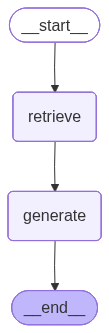

In [5]:
# Display the graph structure
from IPython.display import Image, display

try:
    display(Image(rag_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(rag_graph.get_graph().draw_ascii())

In [9]:
result = rag_graph.invoke({"question": "What vaccinations does my cat need?"})

print("Question:", result["question"])
print("\nRetrieved Documents:")
for i, doc in enumerate(result["context"], 1):
    print(f"  {i}. {doc.page_content[:100]}...")
print("\nResponse:")
print(result["response"])

Question: What vaccinations does my cat need?

Retrieved Documents:
  1. deemed necessary based on risk exposure.126 Revaccination against FPV,
FHV-1, and FCV at 6 months of...
  2. Routine, regular use of broad-spectrum products is likely to be
beneﬁcial for the majority of pet ca...
  3. VETERINARY PRACTICE GUIDELINES
2021 AAHA/AAFP Feline Life Stage Guidelines*
Jessica Quimby, DVM, PhD...

Response:
**Core feline vaccines (every cat)**  
| Vaccine | What it protects against | Typical schedule (based on the guidelines) |
|---------|-------------------------|---------------------------------------------|
| **Rabies virus** | Rabies | One dose (when first introduced to the clinic), then revaccinated per state or provincial law (often every 1–3 years) |
| **Feline herpesvirus‑1 (FHV‑1)** | Feline viral respiratory disease | Part of the initial kitten series; revaccinated at 6 months to shorten the window of susceptibility for kittens still protected by maternal antibodies |
| **Feline c

In [10]:
result2 = rag_graph.invoke({"question": "How can I tell if my cat is sick?"})

print("Question:", result2["question"])
print("\nResponse:")
print(result2["response"])

Question: How can I tell if my cat is sick?

Response:
**How to detect illness in a cat – key red‑flags to watch for**

| Category | What to look for | Why it matters |
|----------|------------------|----------------|
| **Digestive signs** | • Vomiting (including hairballs)<br>• Diarrhea or frequent loose stools | Cats often hide medical problems; vomiting or hairballs may be treated as “normal.” In a mature or senior cat, repeated episodes or changes in frequency should prompt veterinary evaluation.<br>• Weight gain or loss | A sudden drop in weight suggests chronic GI disease, absorption problems, or other systemic disease. |
| **Appetite & thirst** | • Decrease or increase in food intake<br>• Polyuria (frequent urination) and polydipsia (increased water intake) | Loss of appetite or excessive thirst/urination can be early signals of endocrine disorders (e.g., diabetes, thyroid disease), kidney disease, or other metabolic conditions. |
| **Activity patterns** | • Reduced exercise tol

 # Comparing Fireworks vs gpt-4.0-mini

In [19]:
from uuid import uuid4

if not os.environ.get("LANGSMITH_API_KEY"):
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass("Enter your LangSmith API key: ")

PROJECT_ID = uuid4().hex[:8]

print(f"LangSmith tracing enabled!")
print(f"Project: {os.environ['LANGCHAIN_PROJECT']}")

LangSmith tracing enabled!
Project: AIE9-LLM-Servers-2


In [31]:
# Ensure OpenAI API key is set
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

## Create OpenAI-powered RAG Graph

Build an equivalent RAG graph using OpenAI's gpt-4.1-mini for comparison.

In [24]:
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

openai_llm = ChatOpenAI(model="gpt-4.1-mini")
openai_embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

openai_vectorstore = QdrantVectorStore.from_documents(
    documents=chunks,
    embedding=openai_embeddings,
    location=":memory:",
    collection_name="cat_health_openai"
)
openai_retriever = openai_vectorstore.as_retriever(search_kwargs={"k": 3})

# OpenAI RAG prompt (same as Fireworks)
OPENAI_RAG_PROMPT = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful veterinary assistant specializing in cat health. Answer questions based ONLY on the provided context from the cat health guide. If the answer is not in the context, say 'I don't have information about that in the guide.'"),
    ("human", """Context:
{context}

Question: {question}

Answer based on the context above:""")
])


def openai_retrieve(state: RAGState) -> dict:
    """Retrieve using OpenAI embeddings."""
    docs = openai_retriever.invoke(state["question"])
    return {"context": docs}


def openai_generate(state: RAGState) -> dict:
    """Generate using OpenAI LLM."""
    context_text = "\n\n".join([doc.page_content for doc in state["context"]])
    chain = OPENAI_RAG_PROMPT | openai_llm | StrOutputParser()
    response = chain.invoke({
        "context": context_text,
        "question": state["question"]
    })
    return {"response": response}


# Build OpenAI RAG graph
openai_graph_builder = StateGraph(RAGState)
openai_graph_builder.add_node("retrieve", openai_retrieve)
openai_graph_builder.add_node("generate", openai_generate)
openai_graph_builder.add_edge(START, "retrieve")
openai_graph_builder.add_edge("retrieve", "generate")
openai_graph_builder.add_edge("generate", END)

openai_rag_graph = openai_graph_builder.compile()

print("OpenAI RAG graph compiled successfully!")

OpenAI RAG graph compiled successfully!


In [35]:
test_questions = [
    "What vaccinations does my cat need?",
    "How can I tell if my cat is sick?",
    "What should I feed my kitten?",
    "How often should I take my cat to the vet?"
]

print(f"Prepared {len(test_questions)} test questions")

Prepared 4 test questions


In [36]:
from ragas import evaluate
from ragas.metrics import Faithfulness, LLMContextPrecisionWithoutReference
from ragas.llms import LangchainLLMWrapper

# Evaluator LLM for RAGAS
evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

# Run both RAG systems and collect results
def collect_rag_results(graph, questions, name):
    results = []
    for q in questions:
        print(f"[{name}] {q[:50]}...")
        result = graph.invoke({"question": q})
        results.append({
            "question": q,
            "response": result["response"],
            "contexts": [doc.page_content for doc in result["context"]]
        })
    return results

print("Running Fireworks RAG...")
fireworks_results = collect_rag_results(rag_graph, test_questions, "Fireworks")

print("\nRunning OpenAI RAG...")
openai_results = collect_rag_results(openai_rag_graph, test_questions, "OpenAI")

print("\nDone collecting results!")

/var/folders/vv/l_xmncsj59gbr7ptc7h1ghvm0000gn/T/ipykernel_77080/840349346.py:2: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, LLMContextPrecisionWithoutReference
/var/folders/vv/l_xmncsj59gbr7ptc7h1ghvm0000gn/T/ipykernel_77080/840349346.py:2: DeprecationWarning: Importing LLMContextPrecisionWithoutReference from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextPrecisionWithoutReference
  from ragas.metrics import Faithfulness, LLMContextPrecisionWithoutReference
/var/folders/vv/l_xmncsj59gbr7ptc7h1ghvm0000gn/T/ipykernel_77080/840349346.py:6: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from 

Running Fireworks RAG...
[Fireworks] What vaccinations does my cat need?...
[Fireworks] How can I tell if my cat is sick?...
[Fireworks] What should I feed my kitten?...
[Fireworks] How often should I take my cat to the vet?...

Running OpenAI RAG...
[OpenAI] What vaccinations does my cat need?...
[OpenAI] How can I tell if my cat is sick?...
[OpenAI] What should I feed my kitten?...
[OpenAI] How often should I take my cat to the vet?...

Done collecting results!


In [37]:
import pandas as pd
from ragas import EvaluationDataset

def to_ragas_df(results):
    return pd.DataFrame({
        "user_input": [r["question"] for r in results],
        "response": [r["response"] for r in results],
        "retrieved_contexts": [r["contexts"] for r in results],
    })

fireworks_df = to_ragas_df(fireworks_results)
openai_df = to_ragas_df(openai_results)

fireworks_dataset = EvaluationDataset.from_pandas(fireworks_df)
openai_dataset = EvaluationDataset.from_pandas(openai_df)

metrics = [Faithfulness(), LLMContextPrecisionWithoutReference()]

print(f"Created datasets with {len(test_questions)} samples each")
print(f"Metrics: {[m.__class__.__name__ for m in metrics]}")

Created datasets with 4 samples each
Metrics: ['Faithfulness', 'LLMContextPrecisionWithoutReference']


In [38]:
# Evaluate Fireworks RAG
print("Evaluating Fireworks RAG...")
fireworks_eval = evaluate(dataset=fireworks_dataset, metrics=metrics, llm=evaluator_llm)
print("Fireworks Results:")
fireworks_eval

Evaluating Fireworks RAG...


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Fireworks Results:


{'faithfulness': 0.8384, 'llm_context_precision_without_reference': 1.0000}

In [39]:
# Evaluate OpenAI RAG
print("Evaluating OpenAI RAG...")
openai_eval = evaluate(dataset=openai_dataset, metrics=metrics, llm=evaluator_llm)
print("OpenAI Results:")
openai_eval

Evaluating OpenAI RAG...


Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

OpenAI Results:


{'faithfulness': 0.9500, 'llm_context_precision_without_reference': 0.9583}